# TF-IDF vs BM25: Which Algorithm Finds Better Science Papers?

When you type a search query, something has to decide which documents are most relevant and rank them. In this notebook, we pit two classic algorithms against each other on the **SciFact** scientific dataset:

- **TF-IDF** — the straightforward baseline: the more a query word appears in a document, the higher it scores.
- **BM25** — the smarter upgrade: same idea, but it stops rewarding repetition after a point, and normalises for document length.

| Step | What we do |
|------|------------|
| 1 | Load the dataset |
| 2 | Visualise the corpus |
| 3 | Tokenise text |
| 4 | Build the TF-IDF engine |
| 5 | Build the BM25 engine |
| 6 | Evaluate & compare both |
| 7 | Tune BM25 hyperparameters |

## The Dataset: SciFact

SciFact is a collection of scientific claims — each one needs to be matched against the correct paper abstract.

| | |
|--|--|
| **Papers in the corpus** | ~5,183 abstracts |
| **Search queries** | 1,409 scientific claims |
| **Answer key (qrels)** | Human-labelled: which abstract answers which claim |

## Step 1: Load the Data

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from src.data_loader import load_dataset, tokenize_dataset

corpus, queries, qrels_train, qrels_test, qrels_all = load_dataset()

--- Dataset Statistics ---
Total documents in corpus       : 5183
Total queries                   : 1109
Queries with TRAIN answer keys  : 809
Queries with TEST  answer keys  : 300
Total queries with answer keys  : 1109


In [2]:
# Quick sanity check on relevance labels
relevant   = sum(sum(1 for s in docs.values() if s > 0) for docs in qrels_all.values())
irrelevant = sum(sum(1 for s in docs.values() if s == 0) for docs in qrels_all.values())
print(f'Relevant query-document pairs  : {relevant}')
print(f'Irrelevant query-document pairs: {irrelevant}')

Relevant query-document pairs  : 1258
Irrelevant query-document pairs: 0


## Step 2: Dataset Visualisation

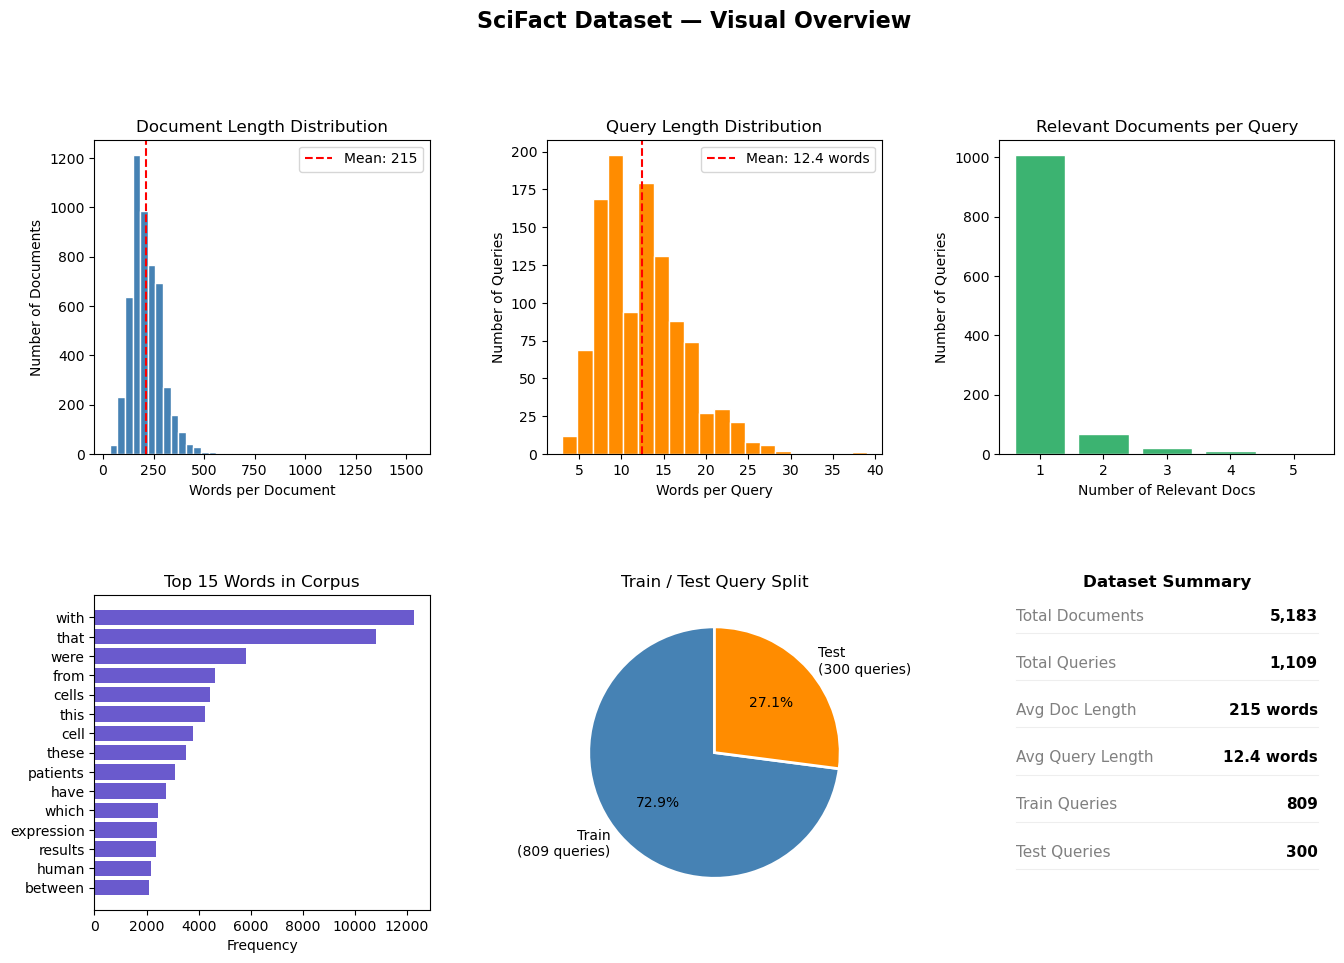

Dataset visualization complete.


In [3]:
from src.visualization import plot_dataset_overview

plot_dataset_overview(corpus, queries, qrels_train, qrels_test, qrels_all)

## Step 3: Tokenisation

> **Why keep stopwords?**  
> BM25's IDF component naturally down-weights common words (words that appear in almost every document get near-zero IDF), so explicit stopword removal is redundant — and could accidentally strip meaningful words like *"not"* that flip a claim's meaning in scientific text.

In [4]:
tokenized_corpus, tokenized_queries = tokenize_dataset(corpus, queries)

# Verify
sample_id = list(queries.keys())[0]
print("Original :", queries[sample_id])
print("Tokenised:", tokenized_queries[sample_id])

Original : 0-dimensional biomaterials lack inductive properties.
Tokenised: ['0dimensional', 'biomaterials', 'lack', 'inductive', 'properties']


## Step 4: TF-IDF Baseline

The baseline uses **pure additive TF-IDF** (no length normalisation) with `sklearn`.  
For each query, we sum the raw TF×IDF weights of matching terms across the corpus matrix.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

corpus_ids     = list(tokenized_corpus.keys())
corpus_strings = [" ".join(tokens) for tokens in tokenized_corpus.values()]

vectorizer = TfidfVectorizer(norm=None)
X_corpus   = vectorizer.fit_transform(corpus_strings)
vocab      = vectorizer.vocabulary_

print(f"Corpus TF-IDF matrix shape: {X_corpus.shape}")

Corpus TF-IDF matrix shape: (5183, 50625)


In [6]:
# Retrieve top-10 docs per query using direct TF-IDF score summation
tfidf_rankings = {}

for query_id, query_tokens in tokenized_queries.items():
    scores = np.zeros(len(corpus_ids))

    for token in query_tokens:
        if token in vocab:
            col_idx     = vocab[token]
            word_scores = X_corpus[:, col_idx].toarray().flatten()
            scores     += word_scores

    top_indices = np.argsort(scores)[-10:][::-1]
    tfidf_rankings[query_id] = [(corpus_ids[i], scores[i]) for i in top_indices]

print(f"TF-IDF rankings built for {len(tfidf_rankings)} queries.")

TF-IDF rankings built for 1109 queries.


In [7]:
# Verification: inspect top-3 results for the first query
sample_id = list(tfidf_rankings.keys())[0]
print(f"Query: {queries[sample_id]}\n")
for rank, (doc_id, score) in enumerate(tfidf_rankings[sample_id][:3], 1):
    label = '✅ Relevant' if qrels_all.get(sample_id, {}).get(doc_id, 0) > 0 else '❌ Not Relevant'
    print(f"Rank {rank} | Score: {score:.4f} | {label}")
    print(f"Title: {corpus[doc_id].get('title', '')}")
    print("-" * 60)

Query: 0-dimensional biomaterials lack inductive properties.

Rank 1 | Score: 22.1172 | ❌ Not Relevant
Title: Lack of Absent in Melanoma 2 (AIM2) expression in tumor cells is closely associated with poor survival in colorectal cancer patients.
------------------------------------------------------------
Rank 2 | Score: 20.9837 | ❌ Not Relevant
Title: Computational and Statistical Analyses of Amino Acid Usage and Physico-Chemical Properties of the Twelve Late Embryogenesis Abundant Protein Classes
------------------------------------------------------------
Rank 3 | Score: 17.6937 | ❌ Not Relevant
Title: Barriers and facilitators to implement shared decision making in multidisciplinary sciatica care: a qualitative study
------------------------------------------------------------


## Step 5: BM25

**BM25** improves on TF-IDF with two key mechanisms:
- **Term saturation** (`k1`): diminishing returns on repeated term occurrences.
- **Length normalisation** (`b`): penalises longer documents that gain scores simply by being verbose.

In [8]:
from rank_bm25 import BM25Okapi

corpus_tokens = list(tokenized_corpus.values())
bm25          = BM25Okapi(corpus_tokens)

bm25_rankings = {}
for query_id, query_tokens in tokenized_queries.items():
    scores      = bm25.get_scores(query_tokens)
    top_indices = np.argsort(scores)[-10:][::-1]
    bm25_rankings[query_id] = [(corpus_ids[i], scores[i]) for i in top_indices]

print(f"BM25 rankings built for {len(bm25_rankings)} queries.")

BM25 rankings built for 1109 queries.


In [9]:
# Verification: inspect top-3 results for the first query
sample_id = list(bm25_rankings.keys())[0]
print(f"Query: {queries[sample_id]}\n")
for rank, (doc_id, score) in enumerate(bm25_rankings[sample_id][:3], 1):
    label = '✅ Relevant' if qrels_all.get(sample_id, {}).get(doc_id, 0) > 0 else '❌ Not Relevant'
    print(f"Rank {rank} | Score: {score:.4f} | {label}")
    print(f"Title: {corpus[doc_id].get('title', '')}")
    print("-" * 60)

Query: 0-dimensional biomaterials lack inductive properties.

Rank 1 | Score: 9.2200 | ❌ Not Relevant
Title: Metastatic colonization requires the repression of the epithelial-mesenchymal transition inducer Prrx1.
------------------------------------------------------------
Rank 2 | Score: 9.1065 | ❌ Not Relevant
Title: Extracellular vesicles for drug delivery.
------------------------------------------------------------
Rank 3 | Score: 8.9587 | ❌ Not Relevant
Title: Potent, Selective, and Orally Bioavailable Inhibitors of VPS34 Provide Chemical Tools to Modulate Autophagy in Vivo.
------------------------------------------------------------


## Step 6: Evaluation

We evaluate both systems on three metrics, averaged across all queries:

| Metric | What it measures |
|--------|-----------------|
| **Precision@10** | Of the 10 returned docs, what fraction are relevant? |
| **Recall@10** | Of all relevant docs in the DB, what fraction did we find? |
| **NDCG@10** | Are the most relevant docs ranked at the top? |

In [10]:
from src.evaluation import evaluate_rankings, print_results

tfidf_p, tfidf_r, tfidf_n = evaluate_rankings(tfidf_rankings, qrels_all, k=10)
bm25_p,  bm25_r,  bm25_n  = evaluate_rankings(bm25_rankings,  qrels_all, k=10)

print_results({
    'TF-IDF (raw)': (tfidf_p, tfidf_r, tfidf_n),
    'BM25 (default)': (bm25_p, bm25_r, bm25_n),
})

Model                  P@10        R@10     NDCG@10
---------------------------------------------------
TF-IDF (raw)         0.0551      0.4943      0.3200
BM25 (default)       0.0846      0.7576      0.6380


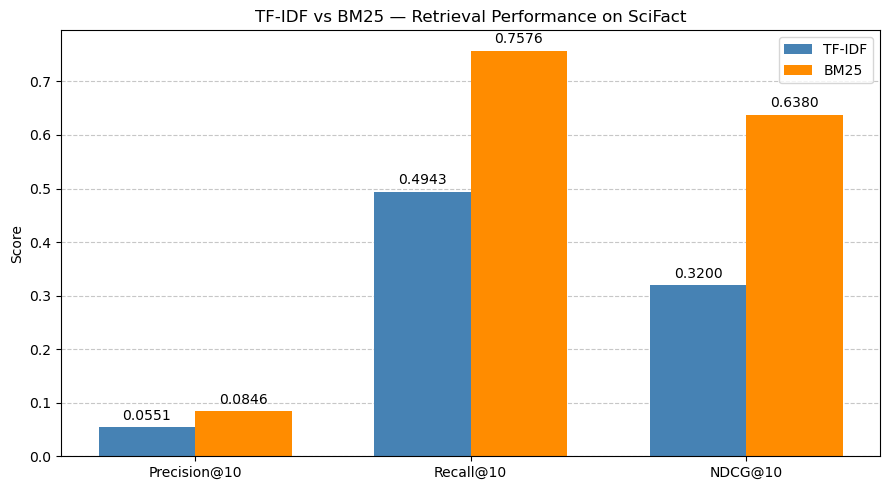

In [11]:
import matplotlib.pyplot as plt
import numpy as np

metrics      = ['Precision@10', 'Recall@10', 'NDCG@10']
tfidf_scores = [tfidf_p, tfidf_r, tfidf_n]
bm25_scores  = [bm25_p,  bm25_r,  bm25_n]

x, width = np.arange(len(metrics)), 0.35
fig, ax  = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(x - width/2, tfidf_scores, width, label='TF-IDF', color='steelblue')
bars2 = ax.bar(x + width/2, bm25_scores,  width, label='BM25',   color='darkorange')

ax.set_ylabel('Score')
ax.set_title('TF-IDF vs BM25 — Retrieval Performance on SciFact')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.legend()
ax.bar_label(bars1, fmt='%.4f', padding=3)
ax.bar_label(bars2, fmt='%.4f', padding=3)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

### Why does BM25 win?

Two structural advantages over raw TF-IDF:

1. **Term saturation** — if a word appears 5× vs 50× in a document, BM25 gives them nearly the same score. Raw TF-IDF rewards documents for being verbose.
2. **Length normalisation** — a short abstract that uses a query word twice is ranked above a long abstract that uses it twice *because there's less "filler"*.

These make BM25 especially well-suited to scientific text, where abstracts vary widely in length.

## Step 7: BM25 Hyperparameter Tuning

In [12]:
import itertools

k1_values = [0.8, 1.2, 1.5, 2.0]
b_values  = [0.4, 0.6, 0.75, 0.9]

best_ndcg, best_params = 0.0, ()
grid_results = {}

print("Running BM25 Grid Search...")
for k1, b in itertools.product(k1_values, b_values):
    bm25_tuned    = BM25Okapi(corpus_tokens, k1=k1, b=b)
    tuned_rankings = {}
    for query_id, query_tokens in tokenized_queries.items():
        scores      = bm25_tuned.get_scores(query_tokens)
        top_indices = np.argsort(scores)[-10:][::-1]
        tuned_rankings[query_id] = [(corpus_ids[i], scores[i]) for i in top_indices]

    _, _, ndcg = evaluate_rankings(tuned_rankings, qrels_all, k=10)
    grid_results[(k1, b)] = ndcg
    print(f"  k1={k1:<4} | b={b:<4}  →  NDCG@10: {ndcg:.4f}")
    if ndcg > best_ndcg:
        best_ndcg, best_params = ndcg, (k1, b)

print(f"\n🏆 Best: k1={best_params[0]}, b={best_params[1]}  |  NDCG@10={best_ndcg:.4f}")

Running BM25 Grid Search...
  k1=0.8  | b=0.4   →  NDCG@10: 0.6333
  k1=0.8  | b=0.6   →  NDCG@10: 0.6367
  k1=0.8  | b=0.75  →  NDCG@10: 0.6371
  k1=0.8  | b=0.9   →  NDCG@10: 0.6406
  k1=1.2  | b=0.4   →  NDCG@10: 0.6324
  k1=1.2  | b=0.6   →  NDCG@10: 0.6396
  k1=1.2  | b=0.75  →  NDCG@10: 0.6393
  k1=1.2  | b=0.9   →  NDCG@10: 0.6376
  k1=1.5  | b=0.4   →  NDCG@10: 0.6351
  k1=1.5  | b=0.6   →  NDCG@10: 0.6394
  k1=1.5  | b=0.75  →  NDCG@10: 0.6380
  k1=1.5  | b=0.9   →  NDCG@10: 0.6372
  k1=2.0  | b=0.4   →  NDCG@10: 0.6316
  k1=2.0  | b=0.6   →  NDCG@10: 0.6392
  k1=2.0  | b=0.75  →  NDCG@10: 0.6390
  k1=2.0  | b=0.9   →  NDCG@10: 0.6373

🏆 Best: k1=0.8, b=0.9  |  NDCG@10=0.6406


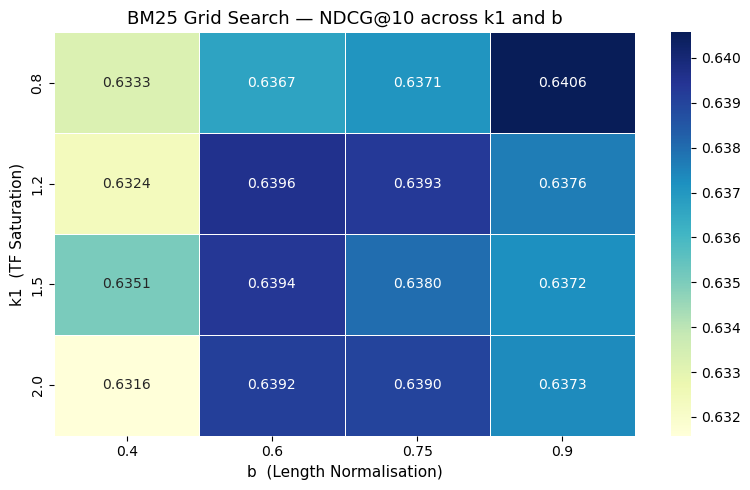

In [13]:
import seaborn as sns
import pandas as pd

heatmap_data = pd.DataFrame(index=k1_values, columns=b_values, dtype=float)
for (k1, b), ndcg in grid_results.items():
    heatmap_data.loc[k1, b] = ndcg

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="YlGnBu",
            linewidths=0.5, linecolor='white')
plt.title("BM25 Grid Search — NDCG@10 across k1 and b", fontsize=13)
plt.xlabel("b  (Length Normalisation)", fontsize=11)
plt.ylabel("k1  (TF Saturation)", fontsize=11)
plt.tight_layout(); plt.show()